In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import beta as beta_dist
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder


## Cart classifier

In [49]:
label_map = {
    'NORMAL':           0,

    # DoS
    'm_sp_na_1_DoS':    1,
    'c_ci_na_1_DoS':    1,
    'c_se_na_1_DoS':    1,
    'c_sc_na_1_DoS':    1,
    'c_rd_na_1_DoS':    1,
    'c_rp_na_1_DoS':    1,

    # Injection
    'c_ci_na_1':        2,
    'c_sc_na_1':        2,
    'c_se_na_1':        2,
    'c_rd_na_1':        2,
    'c_rp_na_1':        2,
}
class_names = {0: 'Normal', 1: 'DoS', 2: 'Injection'}

df = pd.read_csv("iec104_custom_script_train_final.csv")
df['label_merged'] = df['Label'].map(label_map)
df['label_merged'] = df['label_merged'].astype(int)
df = df.select_dtypes(include=['number'])

X = df.drop(columns=['label_merged'])
y = df['label_merged']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(
    criterion='entropy',
    min_impurity_decrease=0.01,
    random_state=42
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# top 15 features
importances = pd.Series(clf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15).index.tolist()

X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

clf_top = DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.01, random_state=42)
clf_top.fit(X_train_top, y_train)
y_pred_top = clf_top.predict(X_test_top)


## Thompson sampling

In [50]:
S_ISOLATE = 0
S_WAIT    = 1

COST_TABLE = {
    0: {S_ISOLATE: 8, S_WAIT: 0},  # Normal: Best to WAIT
    1: {S_ISOLATE: 1, S_WAIT: 9},  # DoS: Best to ISOLATE
    2: {S_ISOLATE: 2, S_WAIT: 8},  # Injection: Best to ISOLATE
}

def get_reward(label_int: int, strategy: int) -> int:
    """Return 1 if chosen strategy has minimum cost for this label integer, else 0."""
    costs = COST_TABLE[label_int]
    best_strategy = min(costs, key=costs.get)
    return 1 if strategy == best_strategy else 0

In [51]:
class ThompsonSampling:
    def __init__(self, n_strategies: int = 2, alpha_init=None, beta_init=None):
        self.n = n_strategies
        self.alpha = np.ones(n_strategies) if alpha_init is None else np.array(alpha_init, dtype=float)
        self.beta  = np.ones(n_strategies) if beta_init  is None else np.array(beta_init,  dtype=float)
        self.history = []

    def sample(self) -> int:
        # draw θ_i ~ Beta(α_i, β_i) for each arm, return argmax
        thetas = np.random.beta(self.alpha, self.beta)
        return int(np.argmax(thetas))

    def update(self, strategy: int, reward: int):
        # bayesian posterior update: α += r, β += (1-r)
        if reward == 1:
            self.alpha[strategy] += 1.0
        else:
            self.beta[strategy]  += 1.0

    def run_episode(self, label_int: list):
        correct = 0
        total   = 0
        accuracies = []

        for i, label in enumerate(label_int):
            strategy = self.sample()
            reward   = get_reward(label, strategy)
            self.update(strategy, reward)

            correct += reward
            total   += 1
            accuracies.append(correct / total)

            self.history.append({
                'event':    i,
                'label':    label,
                'strategy': strategy,
                'reward':   reward,
                'alpha':    self.alpha.copy(),
                'beta':     self.beta.copy(),
            })

        return accuracies

print('ThompsonSampling class defined.')

ThompsonSampling class defined.


In [52]:
class UCBBandit:
    """Upper Confidence Bound baseline — compared against TS in the paper."""
    def __init__(self, n_strategies: int = 2, c: float = 1.0):
        self.n       = n_strategies
        self.c       = c
        self.counts  = np.zeros(n_strategies)
        self.rewards = np.zeros(n_strategies)
        self.t       = 0

    def sample(self) -> int:
        self.t += 1
        # Force exploration in first n rounds
        if self.t <= self.n:
            return self.t - 1
        means = self.rewards / np.maximum(self.counts, 1)
        ucb   = means + self.c * np.sqrt(np.log(self.t) / np.maximum(self.counts, 1))
        return int(np.argmax(ucb))

    def update(self, strategy: int, reward: int):
        self.counts[strategy]  += 1
        self.rewards[strategy] += reward

    def run_episode(self, label_int: list):
        correct = 0
        accuracies = []
        for i, label in enumerate(label_int):
            strategy = self.sample()
            reward   = get_reward(label, strategy)
            self.update(strategy, reward)
            correct += reward
            accuracies.append(correct / (i + 1))
        return accuracies

print('UCBBandit class defined.')

UCBBandit class defined.


In [53]:
predicted_labels = y_pred_top
true_labels      = y_test

print(f'Total security events: {len(predicted_labels)}')
print(f'Attack events: {np.sum(predicted_labels != 0)}')
print(f'Normal events: {np.sum(predicted_labels == 0)}')

# Run TS from uniform prior (cold start)
ts = ThompsonSampling(n_strategies=2)
ts_accuracies = ts.run_episode(predicted_labels.tolist())

# Run UCB for comparison
ucb = UCBBandit(n_strategies=2)
ucb_accuracies = ucb.run_episode(predicted_labels.tolist())

print(f'\n=== Final Mitigation Accuracy ===')
print(f'Thompson Sampling : {ts_accuracies[-1]:.4f}')
print(f'UCB               : {ucb_accuracies[-1]:.4f}')
print(f'\nFinal posteriors:')
print(f'  α = [{ts.alpha[0]:.1f}, {ts.alpha[1]:.1f}]   (s0=isolate, s1=wait)')
print(f'  β = [{ts.beta[0]:.1f},  {ts.beta[1]:.1f}]')

Total security events: 960
Attack events: 880
Normal events: 80

=== Final Mitigation Accuracy ===
Thompson Sampling : 0.9135
UCB               : 0.9094

Final posteriors:
  α = [878.0, 1.0]   (s0=isolate, s1=wait)
  β = [81.0,  4.0]


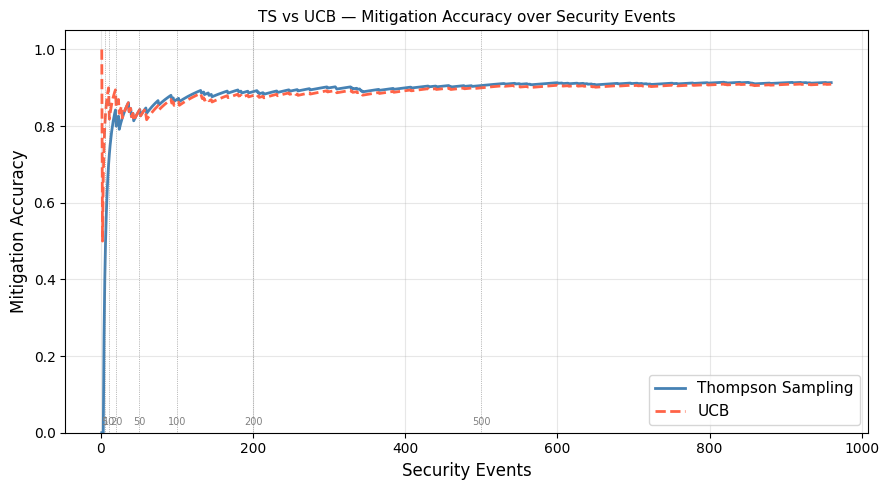

In [54]:
checkpoints = [5, 10, 20, 50, 100, 200, 500, 1000]
checkpoints = [c for c in checkpoints if c <= len(ts_accuracies)]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(range(1, len(ts_accuracies)+1),  ts_accuracies,  label='Thompson Sampling', linewidth=2, color='steelblue')
ax.plot(range(1, len(ucb_accuracies)+1), ucb_accuracies, label='UCB',               linewidth=2, color='tomato', linestyle='--')

# Checkpoint markers
for c in checkpoints:
    if c-1 < len(ts_accuracies):
        ax.axvline(x=c, color='gray', linewidth=0.5, linestyle=':')
        ax.annotate(str(c), xy=(c, 0.02), ha='center', fontsize=7, color='gray')

ax.set_xlabel('Security Events', fontsize=12)
ax.set_ylabel('Mitigation Accuracy', fontsize=12)
ax.set_title('TS vs UCB — Mitigation Accuracy over Security Events', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

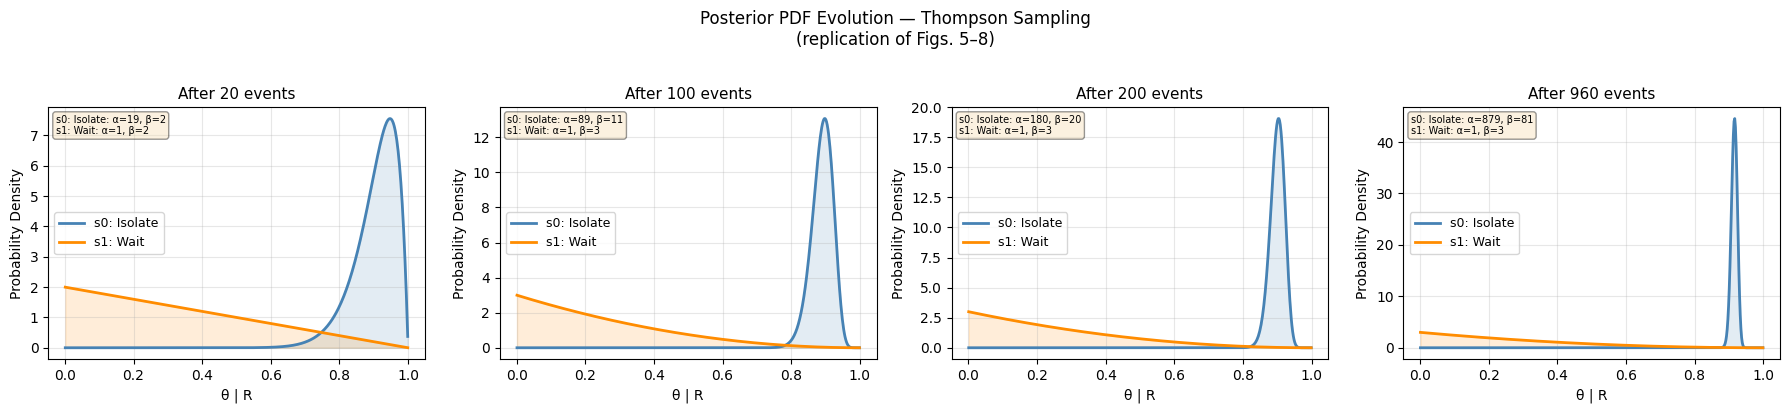

In [55]:
snapshot_events = [20, 100, 200, len(predicted_labels)]

ts_snap = ThompsonSampling(n_strategies=2)
snapshots = {}
all_labels = predicted_labels.tolist()

for i, label in enumerate(all_labels):
    strategy = ts_snap.sample()
    reward   = get_reward(label, strategy)
    ts_snap.update(strategy, reward)
    if (i + 1) in snapshot_events:
        snapshots[i + 1] = {
            'alpha': ts_snap.alpha.copy(),
            'beta':  ts_snap.beta.copy()
        }

# Plot
theta = np.linspace(0.001, 0.999, 500)
strategy_names  = ['s0: Isolate', 's1: Wait']
strategy_colors = ['steelblue', 'darkorange']

n_plots = len(snapshots)
fig, axes = plt.subplots(1, n_plots, figsize=(4.5 * n_plots, 4), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (n_events, snap) in zip(axes, snapshots.items()):
    for i in range(2):
        pdf = beta_dist.pdf(theta, snap['alpha'][i], snap['beta'][i])
        ax.plot(theta, pdf, label=strategy_names[i], color=strategy_colors[i], linewidth=2)
        ax.fill_between(theta, pdf, alpha=0.15, color=strategy_colors[i])
    ax.set_title(f'After {n_events} events', fontsize=11)
    ax.set_xlabel('θ | R', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    info = '\n'.join([f'{strategy_names[j]}: α={snap["alpha"][j]:.0f}, β={snap["beta"][j]:.0f}' for j in range(2)])
    ax.text(0.02, 0.97, info, transform=ax.transAxes, fontsize=7,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

fig.suptitle('Posterior PDF Evolution — Thompson Sampling\n(replication of Figs. 5–8)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [56]:
alpha_trained = ts.alpha
beta_trained  = ts.beta

print('=== Trained Thompson Sampling Posteriors ===')
print(f'Strategy 0 (ISOLATE): α={alpha_trained[0]:.1f}, β={beta_trained[0]:.1f}')
print(f'Strategy 1 (WAIT):    α={alpha_trained[1]:.1f}, β={beta_trained[1]:.1f}')

dominant = 'ISOLATE' if (alpha_trained[0] / (alpha_trained[0] + beta_trained[0])) > \
                        (alpha_trained[1] / (alpha_trained[1] + beta_trained[1])) else 'WAIT'

mean0 = alpha_trained[0] / (alpha_trained[0] + beta_trained[0])
mean1 = alpha_trained[1] / (alpha_trained[1] + beta_trained[1])
print(f'\nPosterior mean θ₀ (isolate): {mean0:.4f}')
print(f'Posterior mean θ₁ (wait):    {mean1:.4f}')
print(f'Dominant strategy: {dominant}')

=== Trained Thompson Sampling Posteriors ===
Strategy 0 (ISOLATE): α=878.0, β=81.0
Strategy 1 (WAIT):    α=1.0, β=4.0

Posterior mean θ₀ (isolate): 0.9155
Posterior mean θ₁ (wait):    0.2000
Dominant strategy: ISOLATE


In [57]:
c_header = f"""
#define TS_N_STRATEGIES   2
#define TS_S_ISOLATE      0    /* Block / alert + block on STM32 */
#define TS_S_WAIT         1    /* Log only, notify on threshold  */

/* Pre-trained Beta posteriors — paste into thompson_init() */
static const float TS_ALPHA_INIT[TS_N_STRATEGIES] = {{
    {alpha_trained[0]:.1f}f,   /* s0: ISOLATE  — alpha */
    {alpha_trained[1]:.1f}f    /* s1: WAIT     — alpha */
}};

static const float TS_BETA_INIT[TS_N_STRATEGIES] = {{
    {beta_trained[0]:.1f}f,    /* s0: ISOLATE  — beta  */
    {beta_trained[1]:.1f}f     /* s1: WAIT     — beta  */
}};

/*
 * Posterior means at deployment:
 *   theta_0 (isolate) = {mean0:.4f}
 *   theta_1 (wait)    = {mean1:.4f}
 *   Dominant strategy : {dominant}
 *
 * Cost table used during training:
 *   dos       -> ISOLATE (cost isolate=1, cost wait=9)
 *   injection -> ISOLATE (cost isolate=2, cost wait=8)
 *   normal    -> WAIT    (cost isolate=8, cost wait=0)
 */
"""

with open('nrm.h', 'w') as f:
    f.write(c_header)
print('Saved: nrm.h')

Saved: nrm.h
